In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/audio-emotions/Emotions/Angry/1014_TAI_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1066_MTI_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1059_DFA_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1056_IEO_ANG_HI.wav
/kaggle/input/audio-emotions/Emotions/Angry/1031_ITS_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/YAF_shack_angry.wav
/kaggle/input/audio-emotions/Emotions/Angry/03-02-05-02-01-01-02.wav
/kaggle/input/audio-emotions/Emotions/Angry/1062_MTI_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1042_IWW_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1005_IWW_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1013_TAI_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1074_MTI_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1073_IOM_ANG_XX.wav
/kaggle/input/audio-emotions/Emotions/Angry/1005_IEO_ANG_MD.wav
/kaggle/input/audio-emotions/Emotions/Angry/03-01-05-02-02-02-15.wav
/kaggle/input/audio-emotions/E

In [2]:
import os
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

2026-01-27 09:49:30.653897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769507370.925902      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769507371.004307      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769507371.640816      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769507371.640884      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769507371.640887      55 computation_placer.cc:177] computation placer alr

In [6]:
# Step 1: Data Preprocessing
def load_audio_data(dataset_path):
    labels = []
    features = []
    
    # Define the audio classes
    class_names = ['Sad', 'Happy', 'Angry']
    
    # Iterate over each class folder
    for label in class_names:
        folder_path = os.path.join(dataset_path, label)
        for filename in os.listdir(folder_path):
            if filename.endswith(".wav"):
                # Load the audio file
                file_path = os.path.join(folder_path, filename)
                audio, sr = librosa.load(file_path, sr=None)
                
                # Extract MFCC features
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)  # Corrected function call
                mfcc = np.mean(mfcc.T, axis=0)  # Take mean across time dimension
                
                # Append features and labels
                features.append(mfcc)
                labels.append(label)
    
    return np.array(features), np.array(labels) 

In [7]:
# Step 2: Load data
dataset_path = '/kaggle/input/audio-emotions/Emotions'  # Path to your dataset
X, y = load_audio_data(dataset_path)

In [8]:
# Step 3: Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y = to_categorical(y, num_classes=3)

# Step 4: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 13, 1, 1)
X_test = X_test.reshape(-1, 13, 1, 1)

In [12]:
# Step 5: Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 1), activation='relu', input_shape=(13, 1, 1)))
model.add(MaxPooling2D((2, 1)))
model.add(Conv2D(64, (3, 1), activation='relu'))
model.add(MaxPooling2D((2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Step 6: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5007 - loss: 1.8982 - val_accuracy: 0.5350 - val_loss: 1.0262
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5968 - loss: 0.8855 - val_accuracy: 0.6211 - val_loss: 0.8283
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6341 - loss: 0.8144 - val_accuracy: 0.6564 - val_loss: 0.7597
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6675 - loss: 0.7270 - val_accuracy: 0.6695 - val_loss: 0.7232
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6935 - loss: 0.6833 - val_accuracy: 0.6749 - val_loss: 0.7316
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6823 - loss: 0.6951 - val_accuracy: 0.6856 - val_loss: 0.7384
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7060 - loss: 0.6564 - val_accuracy: 0.6818 - val_loss: 0.6780
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7016 - loss: 0.6679 - val_accuracy: 0.

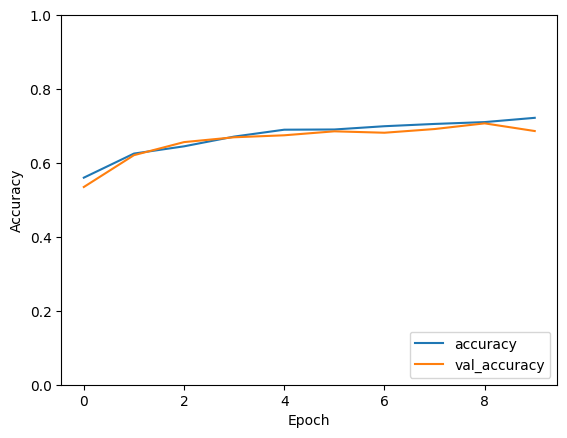

In [13]:
# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Step 8: Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Step 9: Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [16]:
# Save the model after training
model.save('emotion_recognition_model.h5')
print('model saved')


model saved


In [22]:
import librosa
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Step 1: Load the trained model
model = load_model('/kaggle/working/emotion_recognition_model.h5')

# Step 2: Define a function to preprocess the audio
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc.T, axis=0)  # Take the mean across time
    
    # Reshape the features to match the model input (13, 1, 1) for CNN
    mfcc = mfcc.reshape(1, 13, 1, 1)
    
    return mfcc

# Step 3: Make predictions for individual audio files
def predict_emotion(audio_file):
    # Preprocess the audio
    features = preprocess_audio(audio_file)
    
    # Make the prediction
    prediction = model.predict(features)
    
    # Get the predicted class (index of highest probability)
    predicted_class = np.argmax(prediction)
    
    # Map the class index to the emotion label
    class_names = ['Angry', 'Happy', 'Sad']
    predicted_label = class_names[predicted_class]
    
    return predicted_label

# Example Usage: Make a prediction on a single audio file
audio_file = '/kaggle/input/audio-emotions/Emotions/Happy/03-01-03-01-01-01-14.wav'  # Path to the audio file
predicted_emotion = predict_emotion(audio_file)
print(f"The predicted emotion is: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
The predicted emotion is: Happy


In [21]:
import librosa
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Step 1: Load the trained model
model = load_model('/kaggle/working/emotion_recognition_model.h5')

# Step 2: Define a function to preprocess the audio
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc.T, axis=0)  # Take the mean across time
    
    # Reshape the features to match the model input (13, 1, 1) for CNN
    mfcc = mfcc.reshape(1, 13, 1, 1)
    
    return mfcc

# Step 3: Make predictions for individual audio files
def predict_emotion(audio_file):
    # Preprocess the audio
    features = preprocess_audio(audio_file)
    
    # Make the prediction
    prediction = model.predict(features)
    
    # Get the predicted class (index of highest probability)
    predicted_class = np.argmax(prediction)
    
    # Map the class index to the emotion label
    class_names = ['Angry', 'Happy', 'Sad']
    predicted_label = class_names[predicted_class]
    
    return predicted_label

# Example Usage: Make a prediction on a single audio file
audio_file = '/kaggle/input/audio-emotions/Emotions/Angry/03-01-05-01-01-01-07.wav'  # Path to the audio file
predicted_emotion = predict_emotion(audio_file)
print(f"The predicted emotion is: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
The predicted emotion is: Angry


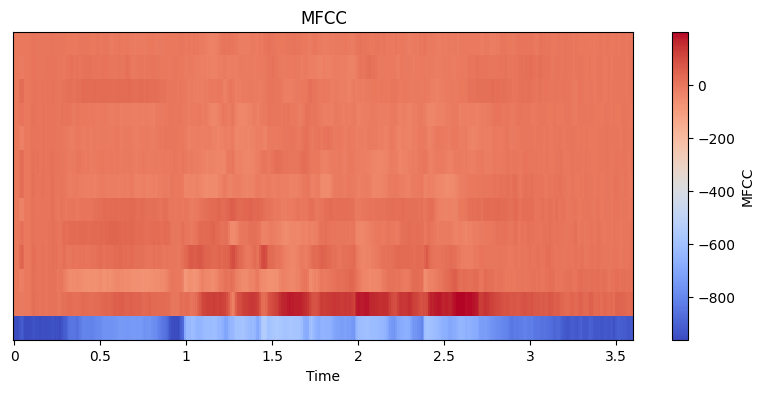

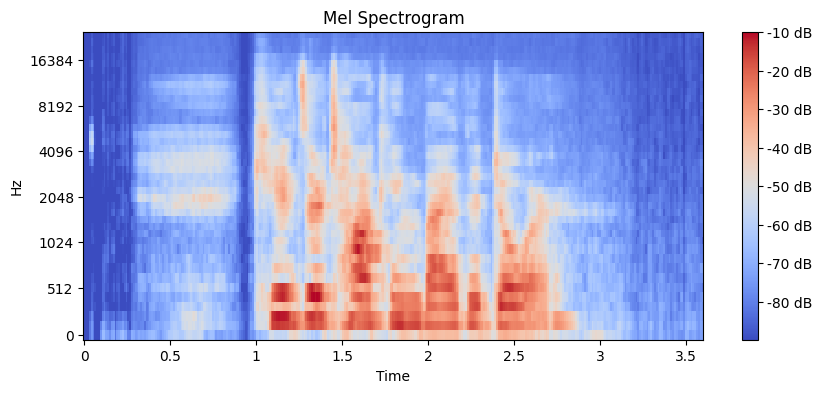

In [25]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the audio file
def load_audio(file_path):
    audio, sr = librosa.load(file_path, sr=None)  # Load audio with its native sample rate
    return audio, sr

# Step 2: Pre-process the audio and extract MFCCs
def extract_mfcc(audio, sr, n_mfcc=13):
    # Step 2.1: Compute the Short-Time Fourier Transform (STFT) of the audio signal
    stft = librosa.stft(audio)
    
    # Step 2.2: Compute Mel-spectrogram (converts STFT to a mel-scaled spectrogram)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=40, fmax=sr/2)
    
    # Step 2.3: Apply logarithmic scaling to the Mel-spectrogram
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)
    
    # Step 2.4: Extract MFCCs from the Mel-spectrogram
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    
    # Return MFCCs and Mel-spectrogram for visualization (optional)
    return mfcc, mel_spectrogram

# Step 3: Plot the MFCC and Mel-spectrogram for visualization
def plot_mfcc(mfcc, mel_spectrogram, sr):
    # Plot MFCCs
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr, cmap='coolwarm')
    plt.colorbar(label='MFCC')
    plt.title('MFCC')
    plt.show()

    # Plot Mel-Spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(librosa.power_to_db(mel_spectrogram), x_axis='time', y_axis='mel', sr=sr, cmap='coolwarm')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')
    plt.show()

# Main function for testing MFCC extraction
def main(file_path):
    # Load the audio file
    audio, sr = load_audio(file_path)
    
    # Extract MFCCs
    mfcc, mel_spectrogram = extract_mfcc(audio, sr)
    
    # Plot and visualize the MFCC and Mel-spectrogram
    plot_mfcc(mfcc, mel_spectrogram, sr)

# Example Usage
file_path = '/kaggle/input/audio-emotions/Emotions/Sad/03-01-04-01-01-02-06.wav'  # Replace with your audio file path
main(file_path)
